In [1]:
import sympy as sm
import sympy.physics.mechanics as me
me.init_vprinting(use_latex='mathjax')

In [2]:
class ReferenceFrame(me.ReferenceFrame):

    def __init__(self, *args, **kwargs):

        kwargs.pop('latexs', None)

        lab = args[0].lower()
        tex = r'\hat{{{}}}_{}'

        super(ReferenceFrame, self).__init__(*args,
                                             latexs=(tex.format(lab, 'x'),
                                                     tex.format(lab, 'y'),
                                                     tex.format(lab, 'z')),
                                             **kwargs)
me.ReferenceFrame = ReferenceFrame

In [3]:
import numpy as np

In [4]:
a, b, c, d = sm.symbols('a, b, c, d')

mat = np.array([[a, b], [c, d]])
mat

array([[a, b],
       [c, d]], dtype=object)

In [5]:
sym_mat = sm.Matrix([[a, b], [c, d]])
eval_sym_mat = sm.lambdify((a, b, c, d), sym_mat)
num_mat = eval_sym_mat(1.0, 2.0, 3.0, 4.0)
num_mat

array([[1., 2.],
       [3., 4.]])

In [6]:
np.cos(5) + sm.cos(5)

0.283662185463226 + cos(5)

In [7]:
m, g, kt, kl, l = sm.symbols('m, g, k_t, k_l, l')
q1, q2, q3 = me.dynamicsymbols('q1, q2, q3')
u1, u2, u3 = me.dynamicsymbols('u1, u2, u3')

N = me.ReferenceFrame('N')
A = me.ReferenceFrame('A')
B = me.ReferenceFrame('B')

A.orient_axis(N, q1, N.z)
B.orient_axis(A, q2, A.x)

A.set_ang_vel(N, u1*N.z)
B.set_ang_vel(A, u2*A.x)

O = me.Point('O')
Ao = me.Point('A_O')
Bo = me.Point('B_O')
Q = me.Point('Q')

Ao.set_pos(O, l/2*A.x)
Bo.set_pos(O, l*A.x)
Q.set_pos(Bo, q3*B.y)

O.set_vel(N, 0)
Ao.v2pt_theory(O, N, A)
Bo.v2pt_theory(O, N, A)
Q.set_vel(B, u3*B.y)
Q.v1pt_theory(Bo, N, B)

t = me.dynamicsymbols._t

qdot_repl = {q1.diff(t): u1,
             q2.diff(t): u2,
             q3.diff(t): u3}

Q.set_acc(N, Q.acc(N).xreplace(qdot_repl))

R_Ao = m*g*N.x
R_Bo = m*g*N.x + kl*q3*B.y
R_Q = m/4*g*N.x - kl*q3*B.y
T_A = -kt*q1*N.z + kt*q2*A.x
T_B = -kt*q2*A.x

I = m*l**2/12
I_A_Ao = I*me.outer(A.y, A.y) + I*me.outer(A.z, A.z)
I_B_Bo = I*me.outer(B.x, B.x) + I*me.outer(B.z, B.z)

points = [Ao, Bo, Q]
forces = [R_Ao, R_Bo, R_Q]
masses = [m, m, m/4]

frames = [A, B]
torques = [T_A, T_B]
inertias = [I_A_Ao, I_B_Bo]

Fr_bar = []
Frs_bar = []

for ur in [u1, u2, u3]:

    Fr = 0
    Frs = 0

    for Pi, Ri, mi in zip(points, forces, masses):
        vr = Pi.vel(N).diff(ur, N)
        Fr += vr.dot(Ri)
        Rs = -mi*Pi.acc(N)
        Frs += vr.dot(Rs)

    for Bi, Ti, Ii in zip(frames, torques, inertias):
        wr = Bi.ang_vel_in(N).diff(ur, N)
        Fr += wr.dot(Ti)
        Ts = -(Bi.ang_acc_in(N).dot(Ii) +
               me.cross(Bi.ang_vel_in(N), Ii).dot(Bi.ang_vel_in(N)))
        Frs += wr.dot(Ts)

    Fr_bar.append(Fr)
    Frs_bar.append(Frs)

Fr = sm.Matrix(Fr_bar)
Frs = sm.Matrix(Frs_bar)

q = sm.Matrix([q1, q2, q3])
u = sm.Matrix([u1, u2, u3])

qd = q.diff(t)
ud = u.diff(t)

ud_zerod = {udr: 0 for udr in ud}

Mk = -sm.eye(3)
gk = u

Md = Frs.jacobian(ud)
gd = Frs.xreplace(ud_zerod) + Fr

In [8]:
q, u, qd, ud

⎛⎡q₁⎤  ⎡u₁⎤  ⎡q₁̇⎤  ⎡u₁̇⎤⎞
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢q₂⎥, ⎢u₂⎥, ⎢q₂̇⎥, ⎢u₂̇⎥⎟
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎝⎣q₃⎦  ⎣u₃⎦  ⎣q₃̇⎦  ⎣u₃̇⎦⎠

In [9]:
Mk, gk

⎛⎡-1  0   0 ⎤  ⎡u₁⎤⎞
⎜⎢          ⎥  ⎢  ⎥⎟
⎜⎢0   -1  0 ⎥, ⎢u₂⎥⎟
⎜⎢          ⎥  ⎢  ⎥⎟
⎝⎣0   0   -1⎦  ⎣u₃⎦⎠

In [10]:
Md, gd

⎛                                                                              ↪
⎜⎡   2      2           2         2    2                                   ⎤   ↪
⎜⎢  l ⋅m⋅cos (q₂)   19⋅l ⋅m   m⋅q₃ ⋅cos (q₂)  l⋅m⋅q₃⋅sin(q₂)  -l⋅m⋅cos(q₂) ⎥   ↪
⎜⎢- ───────────── - ─────── - ──────────────  ──────────────  ─────────────⎥   ↪
⎜⎢       12           12            4               4               4      ⎥   ↪
⎜⎢                                                                         ⎥   ↪
⎜⎢                                               2         2               ⎥   ↪
⎜⎢              l⋅m⋅q₃⋅sin(q₂)                  l ⋅m   m⋅q₃                ⎥,  ↪
⎜⎢              ──────────────                - ──── - ─────        0      ⎥   ↪
⎜⎢                    4                          12      4                 ⎥   ↪
⎜⎢                                                                         ⎥   ↪
⎜⎢              -l⋅m⋅cos(q₂)                                       -m      ⎥   ↪
⎜⎢              ────────────

In [11]:
Mk.free_symbols | gk.free_symbols | Md.free_symbols | gd.free_symbols

{g, kₗ, kₜ, l, m, t}

In [12]:
p = sm.Matrix([g, kl, kt, l, m])
p

⎡g ⎤
⎢  ⎥
⎢kₗ⎥
⎢  ⎥
⎢kₜ⎥
⎢  ⎥
⎢l ⎥
⎢  ⎥
⎣m ⎦

In [13]:
eval_eom = sm.lambdify((q, u, p), [Mk, gk, Md, gd])

In [14]:
q_vals = np.array([
    np.deg2rad(25.0),  # q1, rad
    np.deg2rad(5.0),  # q2, rad
    0.0,  # q3, m
])
q_vals, type(q_vals), q_vals.shape

(array([0.43633231, 0.08726646, 0.        ]), numpy.ndarray, (3,))

In [15]:
u_vals = np.array([
    0.0,  # u1, rad/s
    0.0,  # u2, rad/s
    0.0,  # u3, m/s
])
u_vals, type(u_vals), u_vals.shape

(array([0., 0., 0.]), numpy.ndarray, (3,))

In [16]:
p_vals = np.array([
    9.81,  # g, m/s**2
    0.0,  # kl, N/m
    0.0,  # kt, Nm/rad
    0.6,  # l, m
    1.0,  # m, kg
])
p_vals, type(p_vals), p_vals.shape

(array([9.81, 0.  , 0.  , 0.6 , 1.  ]), numpy.ndarray, (5,))

In [17]:
Mk_vals, gk_vals, Md_vals, gd_vals = eval_eom(q_vals, u_vals, p_vals)
Mk_vals, gk_vals, Md_vals, gd_vals

(array([[-1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0, -1]]),
 array([[0.],
        [0.],
        [0.]]),
 array([[-0.59977212,  0.        , -0.1494292 ],
        [ 0.        , -0.03      ,  0.        ],
        [-0.1494292 ,  0.        , -0.25      ]]),
 array([[-4.35317941],
        [ 0.        ],
        [-1.0325272 ]]))

In [18]:
qd_vals = np.linalg.solve(-Mk_vals, np.squeeze(gk_vals))
qd_vals

array([0., 0., 0.])

In [19]:
ud_vals = np.linalg.solve(-Md_vals, np.squeeze(gd_vals))
ud_vals

array([-7.31898975,  0.        ,  0.24457447])

In [20]:
np.linalg.solve(-Mk_vals, gk_vals)

array([[0.],
       [0.],
       [0.]])

In [21]:
def euler_integrate(rhs_func, t0, tf, m, x0_vals, p_vals):
    """Returns state trajectory and corresponding values of time resulting
    from integrating the ordinary differential equations with Euler's
    Method.

    Parameters
    ==========
    rhs_func : function
       Python function that evaluates the derivative of the state and takes
       this form ``dxdt = f(t, x, p)``.
    t0 : float
      Initial value of time.
    tf : float
      Final value of time.
    m : integer
      Number of time values.
    x0_vals : array_like, shape(2*n,)
       Values of the state x at t0.
    p_vals : array_like, shape(o,)
       Values of constant parameters.

    Returns
    =======
    t : ndarray, shape(m,)
       Monotonically increasing array of time values.
    x : ndarray(m, 2*n)
       State values at each time in t.

    """
    # create an array of time values.
    t = np.linspace(t0, tf, num=m)

    # create an empty array to hold the state values.
    x = np.empty((len(t), len(x0_vals)))

    # set the initial conditions to the first element.
    x[0, :] = x0_vals

    # use a for loop to sequentially calculate each new x.
    for i, ti in enumerate(t[:-1]):
        delt = t[i + 1] - ti
        x[i + 1, :] = x[i, :] + delt*rhs_func(ti, x[i, :], p_vals)

    return t, x

In [22]:
def eval_rhs(t, x, p):
    """Return the right hand side of the explicit ordinary differential
    equations which evaluates the time derivative of the state ``x`` at time
    ``t``.

    Parameters
    ==========
    t : float
       Time in seconds.
    x : array_like, shape(6,)
       State at time t: [q1, q2, q3, u1, u2, u3]
    p : array_like, shape(5,)
       Constant parameters: [g, kl, kt, l, m]

    Returns
    =======
    xd : ndarray, shape(6,)
        Derivative of the state with respect to time at time ``t``.

    """

    # unpack the q and u vectors from x
    q = x[:3]
    u = x[3:]

    # evaluate the equations of motion matrices with the values of q, u, p
    Mk, gk, Md, gd = eval_eom(q, u, p)

    # solve for q' and u'
    qd = np.linalg.solve(-Mk, np.squeeze(gk))
    ud = np.linalg.solve(-Md, np.squeeze(gd))

    # pack dq/dt and du/dt into a new state time derivative vector dx/dt
    xd = np.empty_like(x)
    xd[:3] = qd
    xd[3:] = ud

    return xd

In [23]:
x0 = np.empty(6)
x0[:3] = q_vals
x0[3:] = u_vals
t0 = 0.1
t0, x0

(0.1,
 array([0.43633231, 0.08726646, 0.        , 0.        , 0.        ,
        0.        ]))

In [24]:
eval_rhs(t0, x0, p_vals)

array([ 0.        ,  0.        ,  0.        , -7.31898975,  0.        ,
        0.24457447])

In [25]:
tf = 2.0
ts, xs = euler_integrate(eval_rhs, t0, tf, 51, x0, p_vals)

In [26]:
ts

array([0.1  , 0.138, 0.176, 0.214, 0.252, 0.29 , 0.328, 0.366, 0.404,
       0.442, 0.48 , 0.518, 0.556, 0.594, 0.632, 0.67 , 0.708, 0.746,
       0.784, 0.822, 0.86 , 0.898, 0.936, 0.974, 1.012, 1.05 , 1.088,
       1.126, 1.164, 1.202, 1.24 , 1.278, 1.316, 1.354, 1.392, 1.43 ,
       1.468, 1.506, 1.544, 1.582, 1.62 , 1.658, 1.696, 1.734, 1.772,
       1.81 , 1.848, 1.886, 1.924, 1.962, 2.   ])

In [27]:
type(ts), ts.shape

(numpy.ndarray, (51,))

In [28]:
xs

array([[ 4.36332313e-01,  8.72664626e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.36332313e-01,  8.72664626e-02,  0.00000000e+00,
        -2.78121611e-01,  0.00000000e+00,  9.29382985e-03],
       [ 4.25763692e-01,  8.72664626e-02,  3.53165534e-04,
        -5.56243221e-01, -2.55207423e-04,  1.85876597e-02],
       [ 4.04626449e-01,  8.72567647e-02,  1.05949660e-03,
        -8.28105452e-01, -1.27838385e-03,  2.77100295e-02],
       [ 3.73158442e-01,  8.72081861e-02,  2.11247772e-03,
        -1.08736382e+00, -3.54741664e-03,  3.65046531e-02],
       [ 3.31838617e-01,  8.70733843e-02,  3.49965454e-03,
        -1.32765724e+00, -7.45833243e-03,  4.48433963e-02],
       [ 2.81387642e-01,  8.67899677e-02,  5.20370360e-03,
        -1.54270954e+00, -1.32797097e-02,  5.26337083e-02],
       [ 2.22764679e-01,  8.62853387e-02,  7.20378451e-03,
        -1.72647610e+00, -2.11125195e-02,  5.98184784e-02],
       [ 1.57158587e-01,  8.54830630e-02,  9.476

In [29]:
type(xs), xs.shape

(numpy.ndarray, (51, 6))

In [30]:
import matplotlib.pyplot as plt

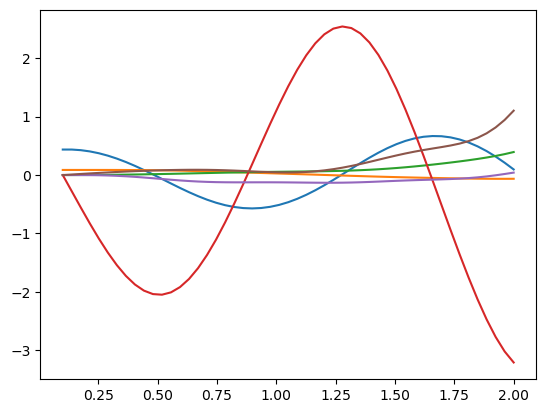

In [31]:
plt.plot(ts, xs);

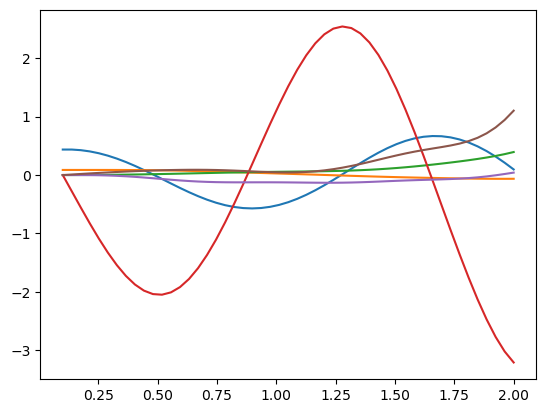

In [32]:
plt.plot(ts, xs)

In [33]:
def plot_results(ts, xs):
    """Returns the array of axes of a 4 panel plot of the state trajectory
    versus time.

    Parameters
    ==========
    ts : array_like, shape(m,)
       Values of time.
    xs : array_like, shape(m, 6)
       Values of the state trajectories corresponding to ``ts`` in order
       [q1, q2, q3, u1, u2, u3].

    Returns
    =======
    axes : ndarray, shape(4,)
       Matplotlib axes for each panel.

    """

    fig, axes = plt.subplots(4, 1, sharex=True)

    fig.set_size_inches((10.0, 6.0))

    axes[0].plot(ts, np.rad2deg(xs[:, :2]))
    axes[1].plot(ts, xs[:, 2])
    axes[2].plot(ts, np.rad2deg(xs[:, 3:5]))
    axes[3].plot(ts, xs[:, 5])

    axes[0].legend([me.vlatex(q[0], mode='inline'),
                    me.vlatex(q[1], mode='inline')])
    axes[1].legend([me.vlatex(q[2], mode='inline')])
    axes[2].legend([me.vlatex(u[0], mode='inline'),
                    me.vlatex(u[1], mode='inline')])
    axes[3].legend([me.vlatex(u[2], mode='inline')])

    axes[0].set_ylabel('Angle [deg]')
    axes[1].set_ylabel('Distance [m]')
    axes[2].set_ylabel('Angular Rate [deg/s]')
    axes[3].set_ylabel('Speed [m/s]')

    axes[3].set_xlabel('Time [s]')

    fig.tight_layout()

    return axes

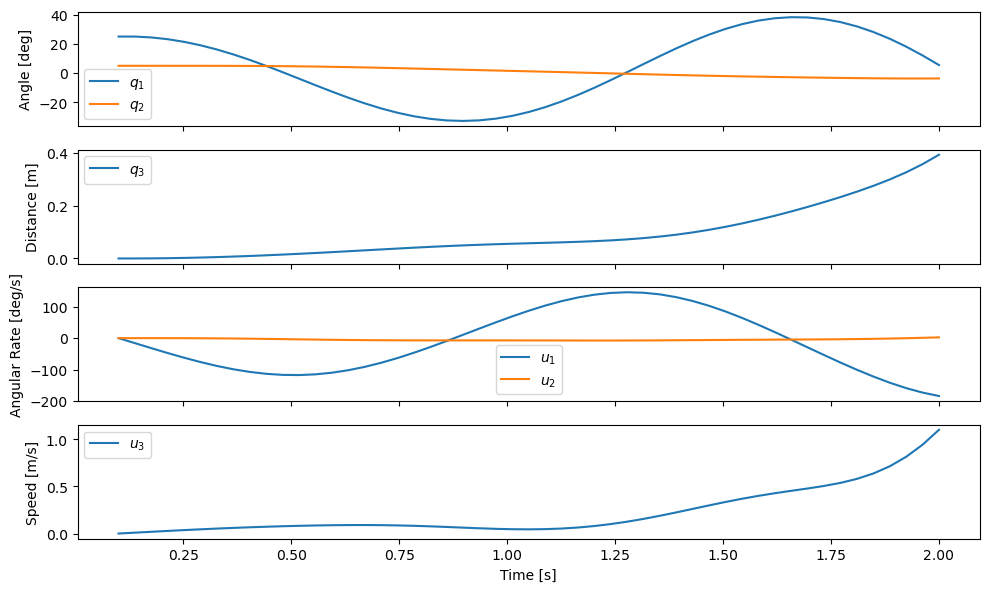

In [34]:
plot_results(ts, xs);

In [35]:
from scipy.integrate import solve_ivp

In [36]:
result = solve_ivp(eval_rhs, (t0, tf), x0, args=(p_vals,))

In [37]:
result.t

array([0.1       , 0.1001918 , 0.10210985, 0.12129032, 0.2264998 ,
       0.36763569, 0.56979903, 0.80426062, 1.07103566, 1.32729219,
       1.58654057, 1.85525322, 2.        ])

In [38]:
result.y

array([[ 4.36332313e-01,  4.36332178e-01,  4.36316023e-01,
         4.34674519e-01,  3.78982019e-01,  1.98103415e-01,
        -1.56844876e-01, -4.31621191e-01, -3.06215830e-01,
         1.16909825e-01,  3.95722264e-01,  2.16631866e-01,
        -3.53554562e-02],
       [ 8.72664626e-02,  8.72664626e-02,  8.72664626e-02,
         8.72663827e-02,  8.71700755e-02,  8.55552906e-02,
         7.56819771e-02,  5.46299752e-02,  2.86798903e-02,
         1.73210738e-03, -2.48594940e-02, -4.69073381e-02,
        -5.30803687e-02],
       [ 0.00000000e+00,  4.49883015e-09,  5.44355824e-07,
         5.54026812e-05,  1.92380685e-03,  8.16085385e-03,
         2.22783441e-02,  4.03399530e-02,  5.48439845e-02,
         7.61828316e-02,  1.30918289e-01,  2.30920868e-01,
         3.16621032e-01],
       [ 0.00000000e+00, -1.40381650e-03, -1.54418048e-02,
        -1.55640609e-01, -8.87645182e-01, -1.60541888e+00,
        -1.69934141e+00, -4.66307989e-01,  1.31061066e+00,
         1.66754280e+00,  2.72931137e

In [39]:
np.shape(result.y)

(6, 13)

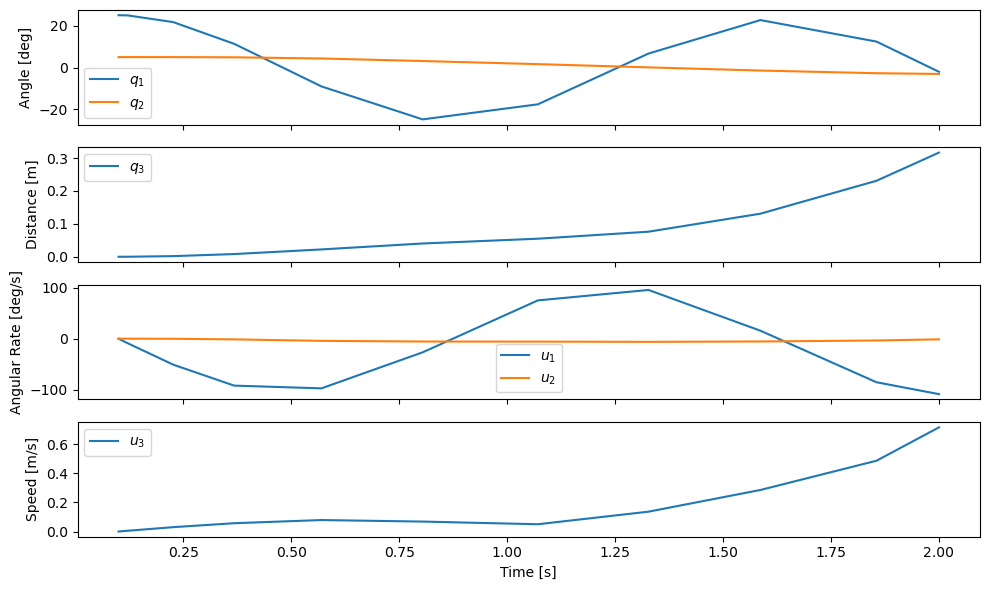

In [40]:
plot_results(result.t, np.transpose(result.y));

In [41]:
result = solve_ivp(eval_rhs, (t0, tf), x0, args=(p_vals,), t_eval=ts)

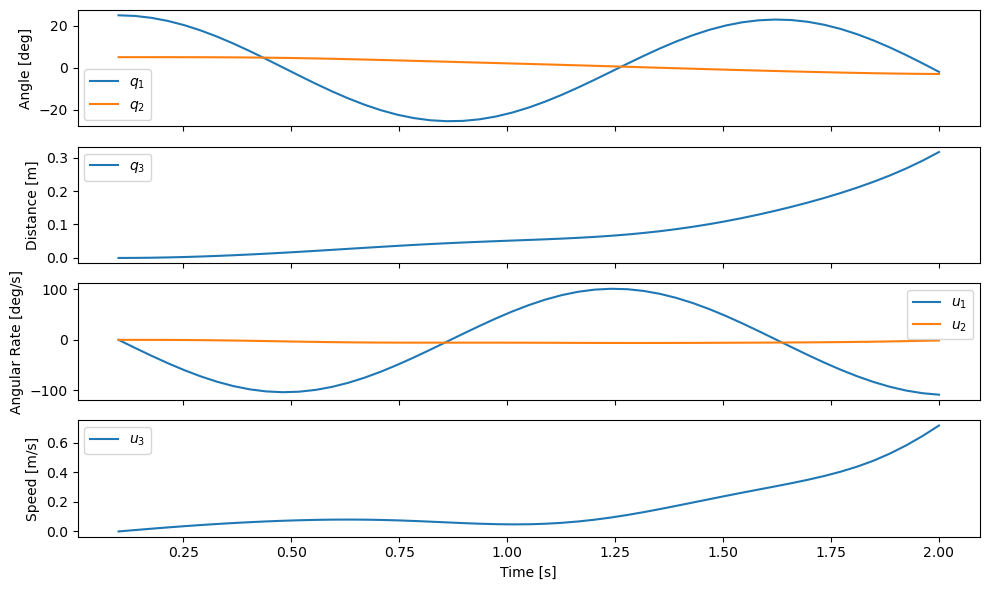

In [42]:
plot_results(result.t, np.transpose(result.y));

In [43]:
np.rad2deg(xs[:, 0] - np.transpose(result.y)[:, 0])

array([ 0.        ,  0.30218768,  0.59643592,  0.86256055,  1.08040825,
        1.23086318,  1.29666888,  1.26279434,  1.11773931,  0.85333362,
        0.46712531, -0.03607564, -0.64673211, -1.35083928, -2.12569935,
       -2.95031892, -3.79816216, -4.63899036, -5.4410806 , -6.17182605,
       -6.79715701, -7.29480713, -7.64315229, -7.81964493, -7.80117057,
       -7.564428  , -7.08801988, -6.36713368, -5.40137322, -4.19938425,
       -2.77980286, -1.16911391,  0.60144339,  2.49278467,  4.44743901,
        6.41505052,  8.34133299, 10.17100318, 11.85090418, 13.33204128,
       14.56708305, 15.51738391, 16.15625989, 16.45842187, 16.39927153,
       15.95464223, 15.10104847, 13.82340456, 12.12644139, 10.02007942,
        7.52836437])

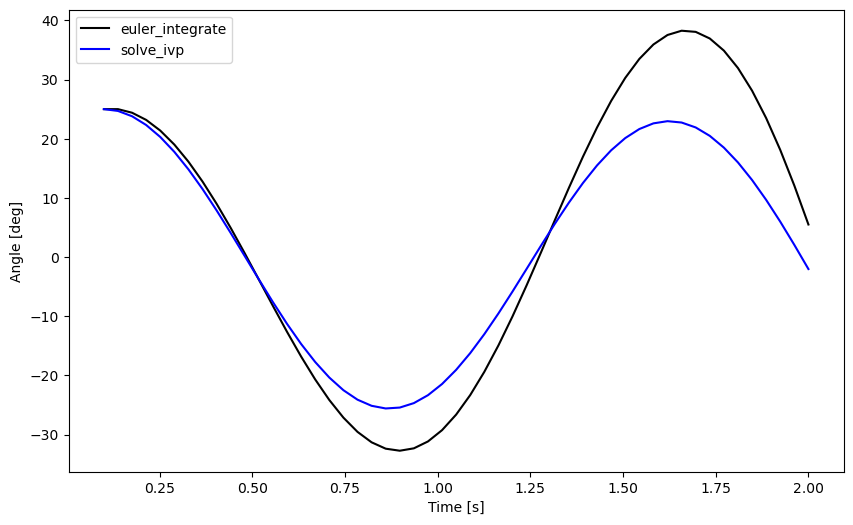

In [44]:
fig, ax = plt.subplots()
fig.set_size_inches((10.0, 6.0))

ax.plot(ts, np.rad2deg(xs[:, 0]), 'k',
        result.t, np.rad2deg(np.transpose(result.y)[:, 0]), 'b');
ax.legend(['euler_integrate', 'solve_ivp'])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Angle [deg]');

In [45]:
xs = np.transpose(result.y)

In [46]:
M = me.ReferenceFrame('M')
M.orient_axis(N, sm.pi/2, N.z)

In [47]:
Bl = me.Point('B_l')
Br = me.Point('B_r')
Bl.set_pos(Bo, -l/2*B.y)
Br.set_pos(Bo, l/2*B.y)

In [48]:
coordinates = O.pos_from(O).to_matrix(M)
for point in [Bo, Q, Bl, Br]:
    coordinates = coordinates.row_join(point.pos_from(O).to_matrix(M))

eval_point_coords = sm.lambdify((q, p), coordinates)
eval_point_coords(q_vals, p_vals)

array([[ 0.        ,  0.25357096,  0.25357096, -0.01728675,  0.52442866],
       [ 0.        , -0.54378467, -0.54378467, -0.67008769, -0.41748165],
       [ 0.        ,  0.        ,  0.        , -0.02614672,  0.02614672]])

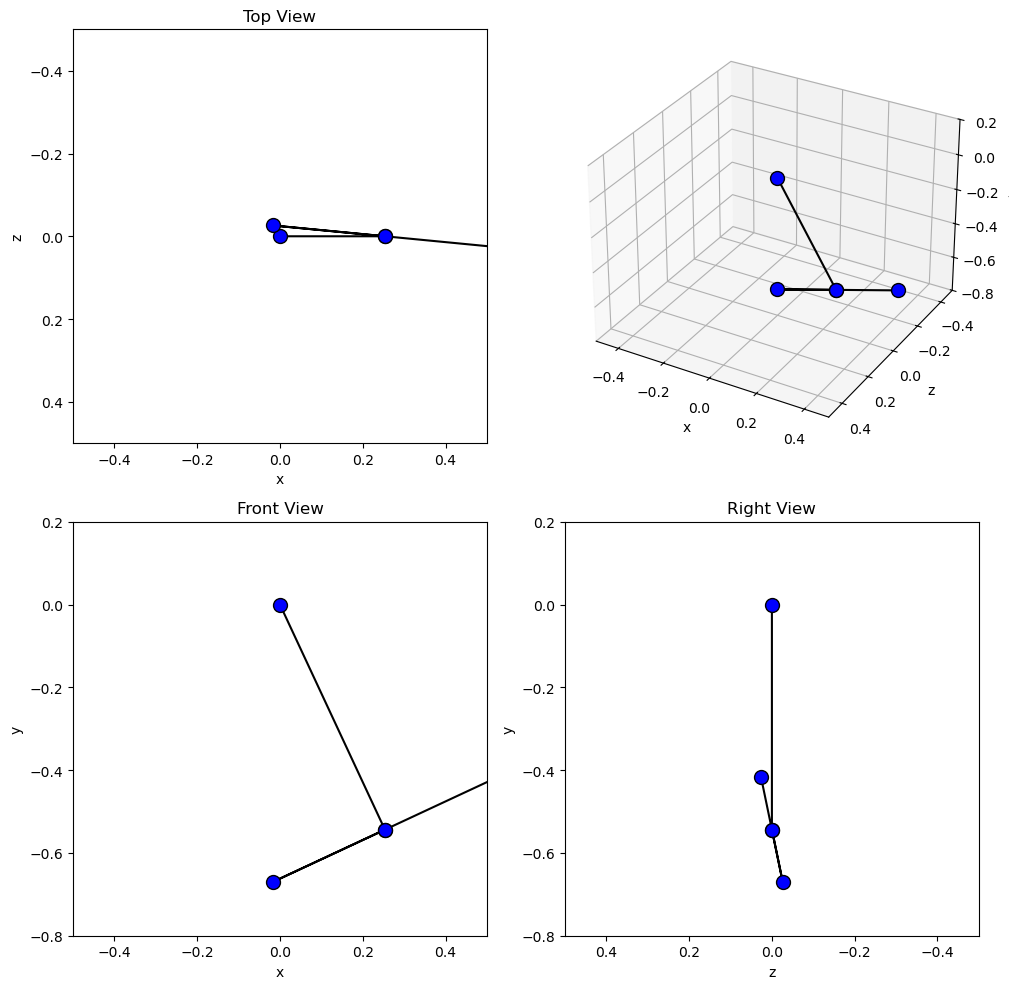

In [49]:
# initial configuration of the points
x, y, z = eval_point_coords(q_vals, p_vals)

# create a figure
fig = plt.figure()
fig.set_size_inches((10.0, 10.0))

# setup the subplots
ax_top = fig.add_subplot(2, 2, 1)
ax_3d = fig.add_subplot(2, 2, 2, projection='3d')
ax_front = fig.add_subplot(2, 2, 3)
ax_right = fig.add_subplot(2, 2, 4)

# common line and marker properties for each panel
line_prop = {
    'color': 'black',
    'marker': 'o',
    'markerfacecolor': 'blue',
    'markersize': 10,
}

# top view
lines_top, = ax_top.plot(x, z, **line_prop)
ax_top.set_xlim((-0.5, 0.5))
ax_top.set_ylim((0.5, -0.5))
ax_top.set_title('Top View')
ax_top.set_xlabel('x')
ax_top.set_ylabel('z')
ax_top.set_aspect('equal')

# 3d view
lines_3d, = ax_3d.plot(x, z, y, **line_prop)
ax_3d.set_xlim((-0.5, 0.5))
ax_3d.set_ylim((0.5, -0.5))
ax_3d.set_zlim((-0.8, 0.2))
ax_3d.set_xlabel('x')
ax_3d.set_ylabel('z')
ax_3d.set_zlabel('y')

# front view
lines_front, = ax_front.plot(x, y, **line_prop)
ax_front.set_xlim((-0.5, 0.5))
ax_front.set_ylim((-0.8, 0.2))
ax_front.set_title('Front View')
ax_front.set_xlabel('x')
ax_front.set_ylabel('y')
ax_front.set_aspect('equal')

# right view
lines_right, = ax_right.plot(z, y, **line_prop)
ax_right.set_xlim((0.5, -0.5))
ax_right.set_ylim((-0.8, 0.2))
ax_right.set_title('Right View')
ax_right.set_xlabel('z')
ax_right.set_ylabel('y')
ax_right.set_aspect('equal')

fig.tight_layout()

In [50]:
from matplotlib.animation import FuncAnimation

In [51]:
def animate(i):
    x, y, z = eval_point_coords(xs[i, :3], p_vals)
    lines_top.set_data(x, z)
    lines_3d.set_data_3d(x, z, y)
    lines_front.set_data(x, y)
    lines_right.set_data(z, y)

In [52]:
ani = FuncAnimation(fig, animate, len(ts))

In [53]:
from IPython.display import HTML

HTML(ani.to_jshtml(fps=30))